In [1]:
from lsst.daf.butler import Butler
from lsst.pipe.tasks.calibrate import CalibrateTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask
from lsst.ip.isr import IsrTask
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lsst.ip.isr import IsrTaskLSST
from lsst.daf.butler import Butler

import inspect

def isr(butler, dataId):
    raw = butler.get("raw", dataId=dataId)

    kwargs = dict(
        bias=butler.get("bias", dataId=dataId),
        dark=butler.get("dark", dataId=dataId),
        flat=butler.get("flat", dataId=dataId),
        ptc=butler.get("ptc", dataId=dataId),
        linearizer=butler.get("linearizer", dataId=dataId),
        crosstalk=butler.get("crosstalk", dataId=dataId),
        defects=butler.get("defects", dataId=dataId),
        camera=butler.get("camera", dataId=dataId),
    )

    # LSST-specific inputs
    try:
        kwargs["deferredChargeCalib"] = butler.get("cti", dataId=dataId)
    except Exception:
        pass

    try:
        kwargs["gainCorrection"] = butler.get("gain_correction", dataId=dataId)
    except Exception:
        pass

    for name in ("bfKernel", "bfk"):
        try:
            kwargs["bfKernel"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    for name in ("electroBFDistortionMatrix", "electroBfDistortionMatrix"):
        try:
            kwargs["electroBfDistortionMatrix"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    cfg = IsrTaskLSST.ConfigClass()
    task = IsrTaskLSST(config=cfg)

    allowed = set(inspect.signature(task.run).parameters.keys())
    kwargs = {k: v for k, v in kwargs.items() if k in allowed}

    res = task.run(raw, **kwargs)
    return res.exposure

In [3]:
def characterizeCalibrate(postISRCCD, threshold=5.0):
    char_config = CharacterizeImageTask.ConfigClass()
    char_config.doApCorr = True
    char_config.doDeblend = True
    # Change the detection threshold
    #char_config.detection.thresholdType = "stdev"
    #char_config.detection.thresholdValue = threshold
    char_task = CharacterizeImageTask(config=char_config)
    char_result = char_task.run(postISRCCD)

    calib_config = CalibrateTask.ConfigClass()
    calib_config.doAstrometry = False
    calib_config.doPhotoCal = False
    # Change the detection threshold
    calib_config.detection.thresholdType = "stdev"
    calib_config.detection.thresholdValue = threshold
    calib_task = CalibrateTask(config=calib_config, icSourceSchema=char_result.sourceCat.schema)
    calib_result = calib_task.run(postISRCCD, background=char_result.background, icSourceCat=char_result.sourceCat)
    return calib_result.outputExposure, calib_result.sourceCat

In [10]:
from lsst.pipe.tasks.calibrateImage import CalibrateImageTask
from lsst.pipe.tasks.calibrateImage import CalibrateImageConfig
import lsst.afw.table as afwTable
import lsst.afw.image as afwImage
import lsst.pipe.base as pipeBase

class CalibrateImageNoRefTask(CalibrateImageTask):
    """Use modern CalibrateImageTask internals, but skip astrometry and photometry."""

    def _fit_astrometry(self, exposure, stars, exposure_region=None):
        # Keep whatever WCS is already on the exposure.
        self.metadata["astrometry_matches_count"] = 0
        self.metadata["initial_to_final_wcs"] = float("nan")
        self.metadata["astrom_offset_mean"] = float("nan")
        self.metadata["astrom_offset_std"] = float("nan")
        self.metadata["astrom_offset_median"] = float("nan")
        return [], None

    def _fit_photometry(self, exposure, stars):
        # Keep instrumental units; attach a trivial PhotoCalib if needed.
        photo_calib = exposure.getPhotoCalib()
        if photo_calib is None:
            photo_calib = afwImage.PhotoCalib(1.0, 0.0, bbox=exposure.getBBox())
            exposure.setPhotoCalib(photo_calib)
        self.metadata["photometry_matches_count"] = 0
        return stars, [], None, photo_calib


def calibrate(postISRCCD, threshold=5.0):
    cfg = CalibrateImageConfig()
    cfg.do_calibrate_pixels = False

    # Do not try to persist empty match catalogs
    cfg.optional_outputs = [
        x for x in cfg.optional_outputs
        if x not in ("astrometry_matches", "photometry_matches")
    ]

    # Optional: expose threshold control similar to old CalibrateTask
    cfg.star_detection.thresholdValue = threshold

    task = CalibrateImageNoRefTask(config=cfg)

    # Skip astrometry quality validation entirely
    task.astrometry.check = lambda *args, **kwargs: None

    result = task.run(exposures=[postISRCCD])

    return result.exposure, result.stars_footprints, result

In [5]:
def footprints_to_label_mask(src_cat, dimensions, dtype=np.uint16):
    """
    Build integer label mask from source footprints.
    0 = background, (idx+1) = source idx in src_cat.
    """
    H, W = int(dimensions.y), int(dimensions.x)
    lab = np.zeros((H, W), dtype=dtype)

    for sid in range(len(src_cat)):
        fp = src_cat[sid].getFootprint()
        label = sid + 1  # 1..N

        # Fill footprint pixels using spans (fast, no per-pixel loops)
        for span in fp.spans:
            y = span.getY()
            if y < 0 or y >= H:
                continue
            x0 = max(span.getX0(), 0)
            x1 = min(span.getX1(), W - 1)
            if x0 <= x1:
                lab[y, x0:x1+1] = label  # overwrite is fine for ignore-mask use
    return lab

In [6]:
repo = "dp2_prep"
collections = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"

butler = Butler(repo, collections=collections)

dataId = {
    "instrument": "LSSTCam",
    "exposure": 2025091900155,
    "visit": 2025091900155,
    "detector": 1,
    "band": "i",
}

In [16]:
!pwd

/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/Notebooks


In [7]:
postISRCCD = isr (butler, dataId)
calexp_charCal, cat_charCal = characterizeCalibrate(postISRCCD)

In [11]:
postISRCCD = isr (butler, dataId)
calexp_calTask, cat_calTask, result = calibrate(postISRCCD)

In [12]:
stack_calexp = butler.get("preliminary_visit_image", dataId=dataId)
stack_catalog = butler.get("single_visit_star_footprints", dataId=dataId)
stack_postISRCCD = butler.get("post_isr_image", dataId=dataId)

In [13]:
print ("Catalog taken from Butler:", len(stack_catalog))
print ("Catalog from characterize + calibrate (depricated way):", len(cat_charCal))
print ("Catalog from Calibrate Image Task (new way):", len(cat_calTask))

Catalog taken from Butler: 640
Catalog from characterize + calibrate (depricated way): 880
Catalog from Calibrate Image Task (new way): 365


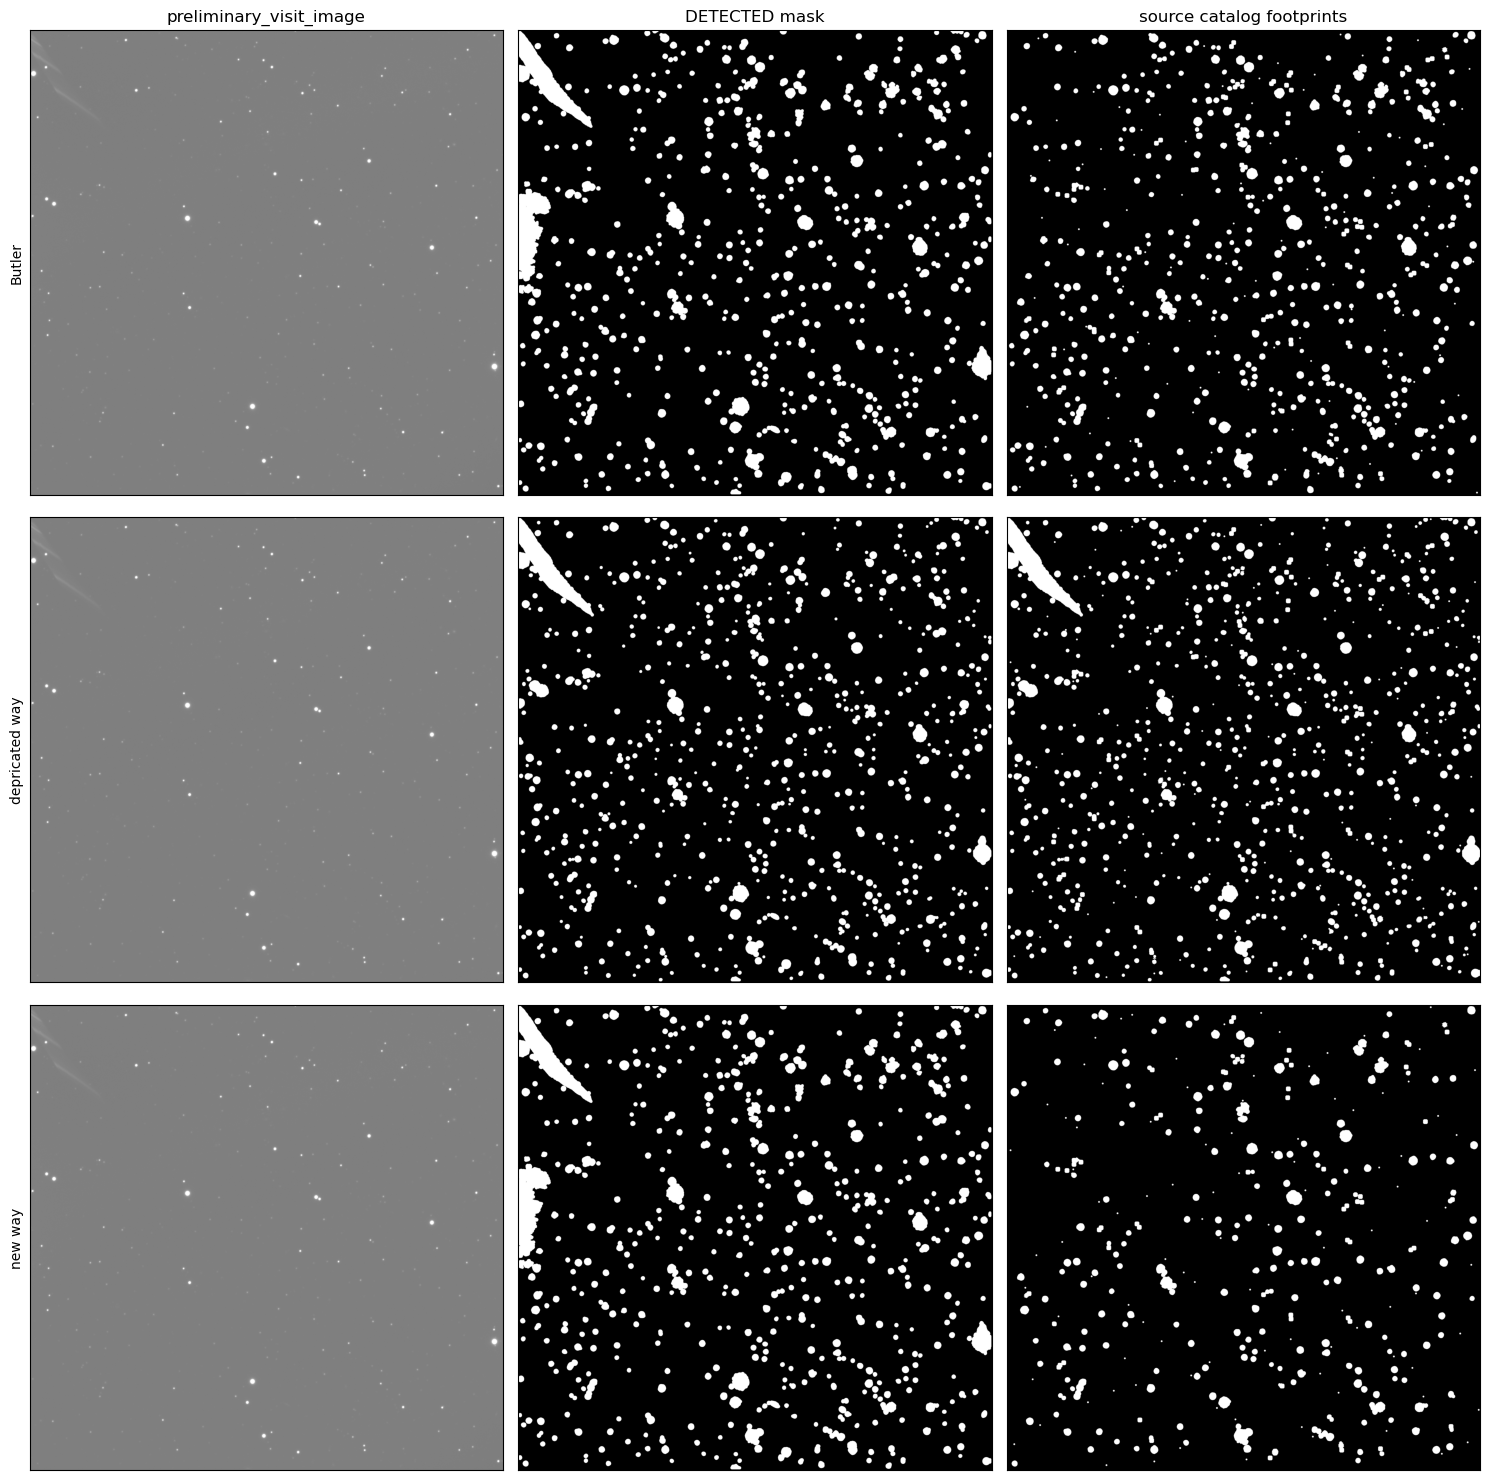

In [15]:
def plot_three(ax, calexp, catalog):
    ax[0].imshow(calexp.image.array, vmin=-5*calexp.image.array.std(), vmax=5*calexp.image.array.std(), cmap="grey")
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].imshow(calexp.mask.array & calexp.mask.getPlaneBitMask("DETECTED"), cmap="grey")
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[2].imshow(footprints_to_label_mask(catalog, calexp.getDimensions())!=0, cmap="grey")
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    return ax

fig, ax = plt.subplots(3,3, figsize=(15,15))
ax[0,0].set_title("preliminary_visit_image")
ax[0,0].set_ylabel("Butler")
ax[0] = plot_three(ax[0], stack_calexp, stack_catalog)
ax[0,1].set_title("DETECTED mask")
ax[1,0].set_ylabel("depricated way")
ax[1] = plot_three(ax[1], calexp_charCal, cat_charCal)
ax[0,2].set_title("source catalog footprints")
ax[2,0].set_ylabel("new way")
ax[2] = plot_three(ax[2], calexp_calTask, cat_calTask)
fig.tight_layout()